<a href="https://colab.research.google.com/github/seo5555/seobyeol/blob/main-quest-01/%EC%98%81%EA%B5%AD_%EC%A4%91%EA%B3%A0%EC%B0%A8_%EA%B0%80%EA%B2%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# 데이터 로딩과 정제

In [3]:
c_df = pd.read_csv('/cars.csv')
b_df = pd.read_csv('/brand.csv')

In [4]:
c_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [5]:
b_df.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


In [14]:
c_df['brand'] = c_df['title'].str.split().str[0].str.lower()
b_df['title'] = b_df['title'].str.lower()

cd_df = pd.merge(c_df, b_df, left_on='brand', right_on='title', how='left')

In [15]:
cd_df.head() # 타이틀 합치기

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,title_y,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,skoda,skoda,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,vauxhall,vauxhall,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,hyundai,hyundai,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,mini,mini,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,vauxhall,vauxhall,United Kingdom


In [16]:
cd_df.drop(['brand', 'title_y'], axis=1, inplace=True) # 복수타이틀 제거

In [18]:
cd_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


In [19]:
cd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title_x            3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
 13  country            3687 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 403.4+ KB


In [20]:
cd_df.drop(columns=['Doors', 'Seats'], inplace=True) # 좌석, 문 수 드랍

In [22]:
cd_df['Engine'] = cd_df['Engine'].str.replace('L', '').astype(float) # 엔진 **L 값 제거

In [23]:
cd_df['Fuel type'] = cd_df['Fuel type'].str.lower()
cd_df['Gearbox'] = cd_df['Gearbox'].str.lower()
cd_df['Body type'] = cd_df['Body type'].str.lower() # 소문자화

In [24]:
cd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title_x            3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   float64
 8   Gearbox            3687 non-null   object 
 9   Emission Class     3600 non-null   object 
 10  Service history    540 non-null    object 
 11  country            3687 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 345.8+ KB


In [25]:
cd_df.isnull().sum()

,0
title_x,0
Price,0
Mileage(miles),0
Registration_Year,0
Previous Owners,1411
Fuel type,0
Body type,0
Engine,45
Gearbox,0
Emission Class,87


In [26]:
cd_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3642.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,1.606260
std,4480.629885,3.941718e+04,5.082387,1.546028,0.486584
min,400.000000,1.000000e+00,1953.000000,1.000000,0.800000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,1.300000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,1.600000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,1.900000
max,33900.000000,1.110100e+06,2025.000000,9.000000,6.300000


In [27]:
cd_df.head()

,title_x,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Emission Class,Service history,country
0,SKODA FABIA,6900,70189,2016,3.0,diesel,hatchback,1.4,manual,Euro 6,NaN,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,petrol,hatchback,1.2,manual,Euro 4,Full,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,petrol,hatchback,1.4,manual,Euro 5,NaN,South Korea
3,MINI HATCH,2395,96731,2010,5.0,petrol,hatchback,1.4,manual,Euro 4,Full,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,diesel,hatchback,1.3,manual,Euro 5,NaN,United Kingdom


In [28]:
median_prev_owners = cd_df['Previous Owners'].median()

cd_df.loc[(cd_df['Previous Owners'].isna()) & (cd_df['Registration_Year'] >= 2020), 'Previous Owners'] = 1

cd_df['Previous Owners'].fillna(median_prev_owners, inplace=True)

/tmp/ipython-input-28-711946760.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cd_df['Previous Owners'].fillna(median_prev_owners, inplace=True)


In [30]:
cd_df.isna().sum()

,0
title_x,0
Price,0
Mileage(miles),0
Registration_Year,0
Previous Owners,0
Fuel type,0
Body type,0
Engine,45
Gearbox,0
Emission Class,87


In [31]:
cd_df[cd_df['Registration_Year'] >= 2020]['Previous Owners'].value_counts()

,count
Previous Owners,
1.0,197
2.0,6
3.0,3


In [35]:
cd_df['Engine'].describe()

,Engine
count,3642.000000
mean,1.606260
std,0.486584
min,0.800000
25%,1.300000
50%,1.600000
75%,1.900000
max,6.300000


In [36]:
median_engine = cd_df['Engine'].median()
cd_df['Engine'].fillna(median_engine, inplace=True)

/tmp/ipython-input-36-4034781035.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cd_df['Engine'].fillna(median_engine, inplace=True)


In [37]:
cd_df['Engine'].isna().sum()

np.int64(0)

In [38]:
cd_df['Emission Class'].isna().sum()

np.int64(87)

In [59]:
cd_df['Emission Class'].fillna('unknown', inplace=True)

In [60]:
cd_df['Emission Class'].unique()

array(['unknown'], dtype=object)

In [61]:
emission_map = {
    'euro 3': 3,
    'euro 4': 4,
    'euro 5': 5,
    'euro 6': 6,
    'unknown': 0
}

cd_df['Emission Class'] = cd_df['Emission Class'].map(emission_map)

In [63]:
cd_df['Emission Class'].value_counts().sort_index()

,count
Emission Class,
0,3687


In [64]:
cd_df.drop(columns=['Emission Class'], inplace=True)

In [65]:
cd_df['Service history'].value_counts(dropna=False)

,count
Service history,
NaN,3147
Full,540


In [66]:
cd_df['Service history'] = cd_df['Service history'].apply(lambda x: 1 if x == 'Full' else 0)

In [67]:
cd_df['Service history'].value_counts()

,count
Service history,
0,3147
1,540


| 항목                                                | 내용                                                          |
| ------------------------------------------------- | ----------------------------------------------------------- |
| 🔹 `Previous Owners`                              | `Registration_Year` 기준으로: 2020년 이상은 `1`, 그 외는 중앙값(`3`)으로 채움 |
| 🔹 `Engine`                                       | `'L'` 문자 제거 후 `float` 변환, 결측값은 중앙값으로 대체                     |
| 🔹 `Fuel type`, `Gearbox`, `Body type`, `country` | 모두 소문자 처리하여 일관성 유지                                          |
| 🔹 `Doors`, `Seats`                               | 분석에 영향 미미하여 제거                                              |
| 🔹 `Emission Class`                               | 전 값이 `'unknown'`이라 의미 없음 → **드랍 처리**                        |
| 🔹 `Service history`                              | `'Full'`은 `1`, 나머지 결측 포함은 `0`으로 변환 (이진 플래그 변수로 단순화)         |
| 🔹 `title` 관련                                     | 브랜드 기준 병합 완료 (`country` 컬럼 있음)                              |
| 🔹 불필요 문자 제거                                      | 없음 (`Mileage`, `Price` 등은 이미 수치형)                           |


In [68]:
cd_df.isna().sum()

,0
title_x,0
Price,0
Mileage(miles),0
Registration_Year,0
Previous Owners,0
Fuel type,0
Body type,0
Engine,0
Gearbox,0
Service history,0


In [72]:
cd_df.rename(columns={'title_x': 'title'}, inplace=True)

In [73]:
cd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    3687 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3687 non-null   float64
 8   Gearbox            3687 non-null   object 
 9   Service history    3687 non-null   int64  
 10  country            3687 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 317.0+ KB


In [74]:
cd_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Service history
count,3687.000000,3.687000e+03,3687.000000,3687.000000,3687.000000,3687.000000
mean,5787.301058,8.132854e+04,2011.846216,2.837809,1.606184,0.146461
std,4480.629885,3.941718e+04,5.082387,1.248440,0.483605,0.353615
min,400.000000,1.000000e+00,1953.000000,1.000000,0.800000,0.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,1.300000,0.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,1.600000,0.000000
75%,7995.000000,1.030000e+05,2015.500000,3.000000,1.900000,0.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,6.300000,1.000000


In [75]:
for col in ['Fuel type', 'Gearbox', 'Body type', 'country']:
    print(f"{col}:", cd_df[col].unique())

Fuel type: ['diesel' 'petrol' 'petrol plug-in hybrid' 'petrol hybrid' 'electric'
 'diesel hybrid']
Gearbox: ['manual' 'automatic']
Body type: ['hatchback' 'coupe' 'estate' 'saloon' 'convertible' 'mpv' 'suv' 'minibus'
 'combi van' 'pickup']
country: ['Czech Republic' 'United Kingdom' 'South Korea' 'United States' 'Sweden'
 'France' 'Germany' 'Japan' 'Spain' 'Italy' 'Malaysia' 'Romania']


## 스케일링

In [76]:
features = [
    'Price',
    'Mileage(miles)',
    'Registration_Year',
    'Previous Owners',
    'Engine',
    'Service history'  # 이진값 (0 or 1)
]
X = cd_df[features]

In [77]:
X

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Service history
0,6900,70189,2016,3.0,1.4,0
1,1495,88585,2008,4.0,1.2,1
2,949,137000,2011,3.0,1.4,0
3,2395,96731,2010,5.0,1.4,1
4,1000,85000,2013,3.0,1.3,0
...,...,...,...,...,...,...
3682,1395,76202,2006,4.0,1.6,0
3683,6990,119000,2012,3.0,2.0,0
3684,3995,139000,2013,3.0,2.0,0
3685,1390,179190,2007,3.0,2.2,1


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [79]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Service history
count,3.687000e+03,3.687000e+03,3.687000e+03,3.687000e+03,3.687000e+03,3.687000e+03
mean,-6.166902e-17,1.695898e-16,-3.746393e-15,-1.541725e-16,2.119873e-16,4.625176e-17
std,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00,1.000136e+00
min,-1.202517e+00,-2.063531e+00,-1.158003e+01,-1.472284e+00,-1.667256e+00,-4.142366e-01
25%,-7.360011e-01,-6.176961e-01,-7.568763e-01,-6.711753e-01,-6.332139e-01,-4.142366e-01
50%,-3.989492e-01,-3.370908e-02,3.026224e-02,1.299329e-01,-1.278880e-02,-4.142366e-01
75%,4.927875e-01,5.498719e-01,7.190084e-01,1.299329e-01,6.076363e-01,-4.142366e-01
max,6.275125e+00,2.610311e+01,2.588462e+00,4.936582e+00,9.707204e+00,2.414079e+00


## PCA적용

In [84]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
import matplotlib.pyplot as plt

In [85]:
# 각 주성분이 설명하는 분산 비율
explained_var_ratio = pca.explained_variance_ratio_

# 누적 설명 분산 비율
cumulative_explained = np.cumsum(explained_var_ratio)

In [86]:
n_components_70 = np.argmax(cumulative_explained >= 0.70) + 1
print(f"👉 70% 이상의 분산을 설명하는 주성분 개수: {n_components_70}")

👉 70% 이상의 분산을 설명하는 주성분 개수: 3


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

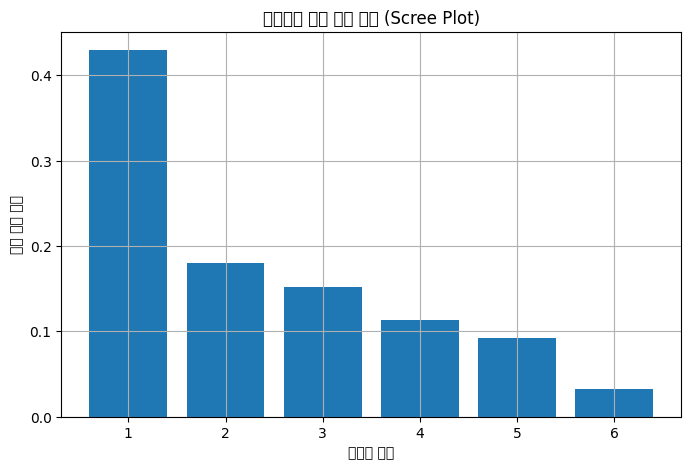

In [87]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var_ratio) + 1), explained_var_ratio)
plt.title('주성분별 설명 분산 비율 (Scree Plot)')
plt.xlabel('주성분 개수')
plt.ylabel('설명 분산 비율')
plt.grid()
plt.show()

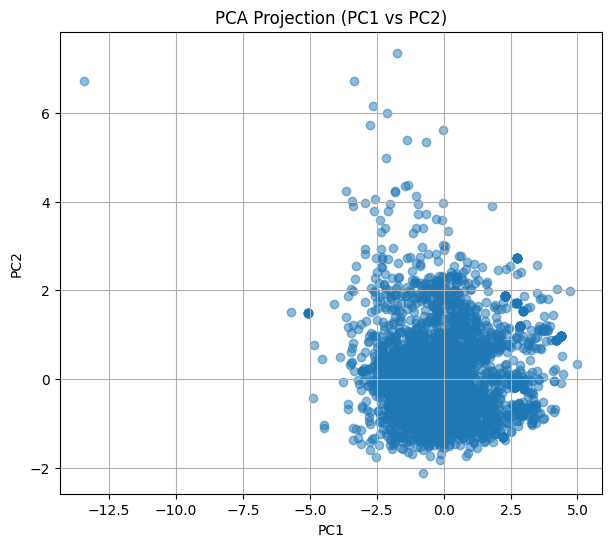

In [88]:
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (PC1 vs PC2)')
plt.grid()
plt.show()

In [90]:
pca = PCA(n_components=3)
X_pca_3 = pca.fit_transform(X_scaled)

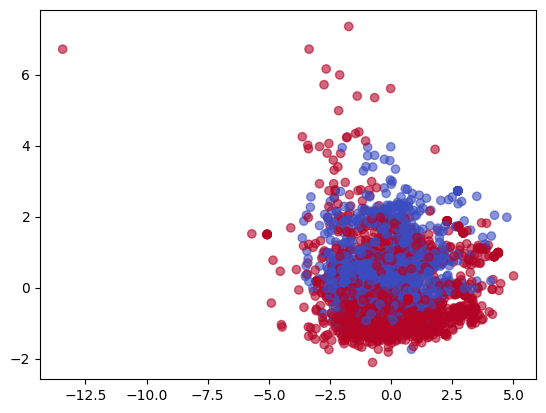

In [91]:
plt.scatter(X_pca_3[:, 0], X_pca_3[:, 1], c=cd_df['Fuel type'].map({'diesel': 0, 'petrol': 1}), cmap='coolwarm', alpha=0.6)

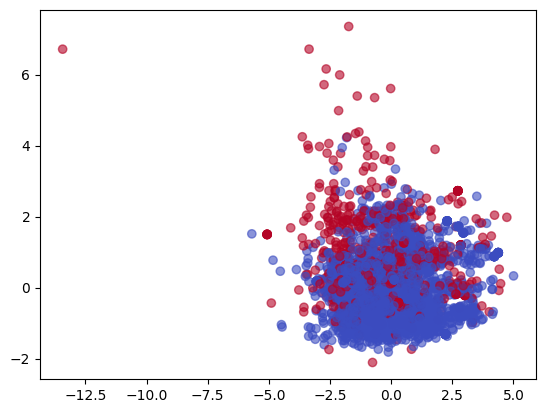

In [92]:
plt.scatter(X_pca_3[:, 0], X_pca_3[:, 1],
            c=cd_df['Gearbox'].map({'manual': 0, 'automatic': 1}),
            cmap='coolwarm', alpha=0.6)

# 국가별 총 브랜드 개수

In [93]:
cd_df['brand'] = cd_df['title'].str.split().str[0].str.lower()

# 국가별 고유 브랜드 개수 계산
brand_counts = cd_df.groupby('country')['brand'].nunique().sort_values(ascending=False)

print(brand_counts)

country
Japan             11
United Kingdom     8
Germany            6
United States      5
France             4
Italy              4
South Korea        4
Sweden             2
Czech Republic     1
Malaysia           1
Romania            1
Spain              1
Name: brand, dtype: int64


변수 간 상관관계 확인

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/l

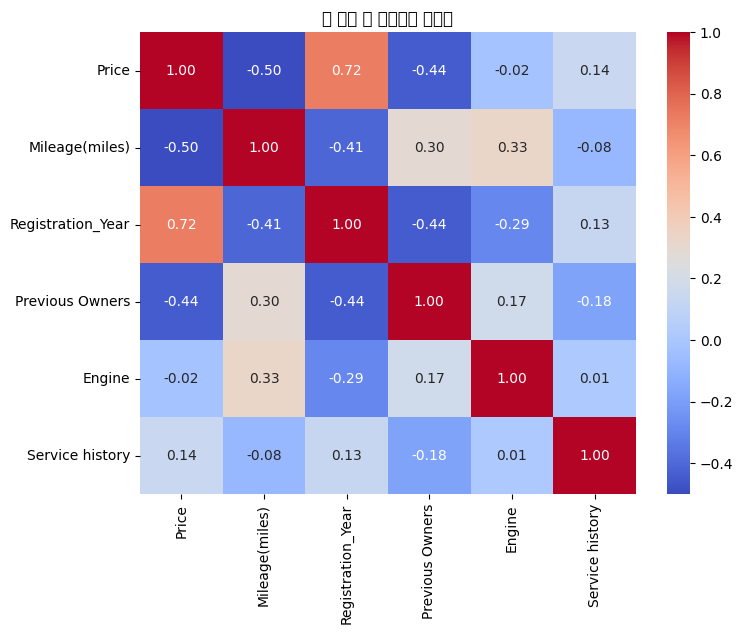

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관관계 행렬 구하기
corr_matrix = cd_df.select_dtypes(include='number').corr()

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📊 변수 간 상관관계 히트맵")
plt.show()

| 변수 조합                           | 상관계수      | 해석 요약                      |
| ------------------------------- | --------- | -------------------------- |
| **Price ↔ Registration Year**   | **+0.72** | 신차일수록 비싸다 (연식이 높을수록 가격 상승) |
| **Price ↔ Mileage**             | **–0.50** | 주행거리가 많을수록 차량 가격이 떨어진다     |
| **Price ↔ Previous Owners**     | –0.44     | 소유자가 많을수록 가격이 떨어지는 경향      |
| **Mileage ↔ Engine**            | +0.33     | 엔진이 클수록 주행거리가 많을 가능성       |
| **Mileage ↔ Registration Year** | –0.41     | 연식이 높을수록 주행거리는 적은 편        |
| **Price ↔ Engine**              | –0.02     | 거의 무상관 (의외로 영향 없음)         |
| **Service history ↔ Price**     | +0.14     | 정비 이력이 있을수록 약간 더 높은 가격 경향  |
